In [66]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print(X.shape, y.shape)

(442, 10) (442,)


/tmp/ipykernel_37610/4274357154.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


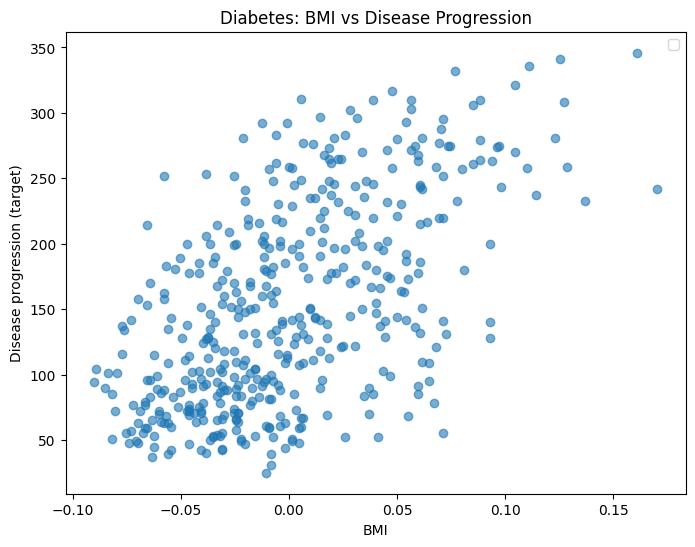

In [67]:
df = X.copy()
df['target'] = y

plt.figure(figsize=(8,6))
plt.scatter(df['bmi'], df['target'], alpha=0.6)

plt.xlabel('BMI')
plt.ylabel('Disease progression (target)')
plt.title('Diabetes: BMI vs Disease Progression')
plt.legend()
plt.show()

In [68]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(1, activation='linear', name='single_neuron')
])
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()
print('\nLayer config:')
print(model.layers[0].get_config())
print('\nWeights and shapes:')
for w in model.weights:
    print(w.name, w.shape)

print('\nExplanation:')
print('- units: 1 (single output neuron)')
print("- activation: linear (suitable for regression)")
print("- kernel shape: (input_dim, units) = (1,1)")
print("- bias shape: (units,) = (1,)")
print('- total params: kernel params + bias params (1 + 1 = 2)')

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ single_neuron (Dense)           │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)


Layer config:
{'name': 'single_neuron', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'quantization_config': None}

Weights and shapes:
kernel (1, 1)
bias (1,)

Explanation:
- units: 1 (single output neuron)
- activation: linear (suitable for regression)
- kernel shape: (input_dim, units) = (1,1)
- bias shape: (units,) = (1,)
- total params: kernel params + bias params (1 + 1 = 2)


In [69]:
X = diabetes.data['bmi'].values.reshape(-1,1)
y = diabetes.target.values

history = model.fit(X, y, epochs=1000, batch_size=16, verbose=1)

kernel = model.layers[-1].kernel.numpy().reshape(-1)[0]
bias = model.layers[-1].bias.numpy().reshape(-1)[0]
print('\nFinal trained parameters:')
print('weight (kernel):', kernel)
print('bias:', bias)

transfer_function = f'y = {kernel:.4f} * x + {bias:.4f}'
print('\nTransfer function derived from trained weight and bias:')
print(transfer_function)

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (SGD + MSE)')
plt.legend()
plt.show()

# Plot raw data and trained transfer function in the same figure
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.6, label='Raw data')
xs = np.linspace(X.min(), X.max(), 100)
plt.plot(xs, kernel * xs + bias, color='red', label=f'Transfer function: {transfer_function}')
plt.xlabel('BMI')
plt.ylabel('Disease progression (target)')
plt.title('Raw Data and Trained Single-Neuron Transfer Function')
plt.legend()
plt.show()

print('\nExplanation:')
print('- Optimizer: SGD (stochastic gradient descent)')
print('- Loss: MSE (mean squared error)')
print('- Units: 1; kernel shape (1,1); bias shape (1,); total params: 2')


Epoch 1/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20170.2832  
Epoch 2/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10516.1240 
Epoch 3/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7392.0400 
Epoch 4/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6388.7354 
Epoch 5/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6069.1226 
Epoch 6/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5956.4438 
Epoch 7/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5921.6382 
Epoch 8/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5904.9243 
Epoch 9/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5898.0645 
Epoch 10/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5888.6504 
Epoch 11/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5889.9380 
Epoch 12/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5876.8584 
Epoch 13/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5874.6567 
Epoch 14/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5869.5933

KeyboardInterrupt: 

Epoch 1/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20182.9570  
Epoch 2/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10531.5332
Epoch 3/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7375.6890 
Epoch 4/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6368.9932 
Epoch 5/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6040.7676 
Epoch 6/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5936.6631 
Epoch 7/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5906.7222 
Epoch 8/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5883.8242 
Epoch 9/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5871.8594 
Epoch 10/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5864.2310 
Epoch 11/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5855.4487 
Epoch 12/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5846.7168 
Epoch 13/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5837.0493 
Epoch 14/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5833.6221 

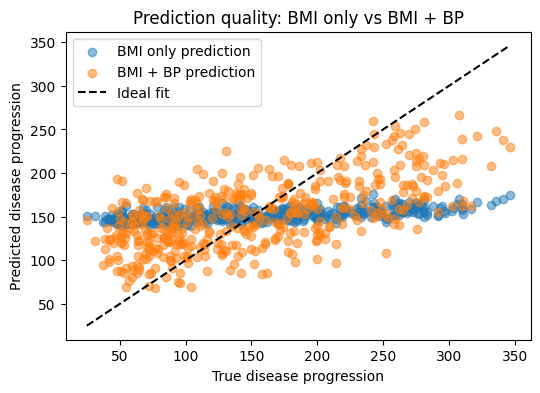


Explanation:
- Using BMI and blood pressure as inputs gives the model two coefficients and one bias.
- The MSE comparison shows whether adding BP improved training accuracy.
- In general, a lower training MSE indicates a better fit to the raw data.


In [72]:
beta = load_diabetes(as_frame=True)
X2 = beta.data[['bmi', 'bp']].values
y = beta.target.values

model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(1, activation='linear', name='output_neuron')
])
model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

history2 = model2.fit(X2, y, epochs=1000, batch_size=16, verbose=1)

kernel2 = model2.layers[-1].kernel.numpy().reshape(-1)
bias2 = model2.layers[-1].bias.numpy().reshape(-1)[0]
print('\nFinal trained parameters for two-feature model:')
print('weights (kernel):', kernel2)
print('bias:', bias2)
print('transfer function: y = {:.4f}*bmi + {:.4f}*bp + {:.4f}'.format(kernel2[0], kernel2[1], bias2))

# Compute training accuracy comparison
X1 = beta.data['bmi'].values.reshape(-1,1)
y_pred_bmi = model.predict(X1).reshape(-1)
y_pred_2 = model2.predict(X2).reshape(-1)
mse_bmi = np.mean((y - y_pred_bmi)**2)
mse_2 = np.mean((y - y_pred_2)**2)
print('\nTraining MSE comparison:')
print('BMI only model MSE:', mse_bmi)
print('BMI + BP model MSE:', mse_2)
print('Improvement in MSE:', mse_bmi - mse_2)

# Plot predictions vs raw data for the two-feature model on the same figure
plt.figure(figsize=(6,4))
plt.scatter(y, y_pred_bmi, alpha=0.5, label='BMI only prediction')
plt.scatter(y, y_pred_2, alpha=0.5, label='BMI + BP prediction')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Ideal fit')
plt.xlabel('True disease progression')
plt.ylabel('Predicted disease progression')
plt.title('Prediction quality: BMI only vs BMI + BP')
plt.legend()
plt.show()

print('\nExplanation:')
print('- Using BMI and blood pressure as inputs gives the model two coefficients and one bias.')
print('- The MSE comparison shows whether adding BP improved training accuracy.')
print('- In general, a lower training MSE indicates a better fit to the raw data.')